In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from collections import Counter
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)

from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [2]:
def plot(ax, filename, db_fixed, dg_fixed, shots):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    rescaling = np.array(res['rescaling'])
    ps = np.array(res['ps'])
    print(rescaling)
    print(np.min(energies))
    
    def log_edges(x):
        return np.concatenate([
            x[:1] / np.sqrt(x[1] / x[0]),
            np.sqrt(x[:-1] * x[1:]),
            x[-1:] * np.sqrt(x[-1] / x[-2])
        ])

    ps_edges = log_edges(ps)
    rescaling_edges = log_edges(rescaling)
    
    cmap = plt.get_cmap()
    cmap.set_over('white')
    
    im = ax.pcolormesh(
        ps_edges,
        rescaling_edges,
        energies.T,      # transpose so shape is (Ny, Nx)
        shading='auto',
        cmap=cmap,
        vmin=0,
        vmax=2
    )

    ax.set_xscale('log')
    xticks = sorted(ps)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_yscale('log')

    ax.set_xlabel('p')
    # ax.set_ylabel('rescaling')

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.set_label('Energy')

    
    ax.set_ylabel(r'$\Delta_\beta / \Delta_{\beta,\text{fixed}} = \Delta_\gamma / \Delta_{\gamma,\text{fixed}}$')
    ax.set_title(f'{filename}, $\\Delta_\\beta = {db_fixed}$, $\\Delta_\\gamma = {dg_fixed}$')
    return ax

[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.0
[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.0
[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.0


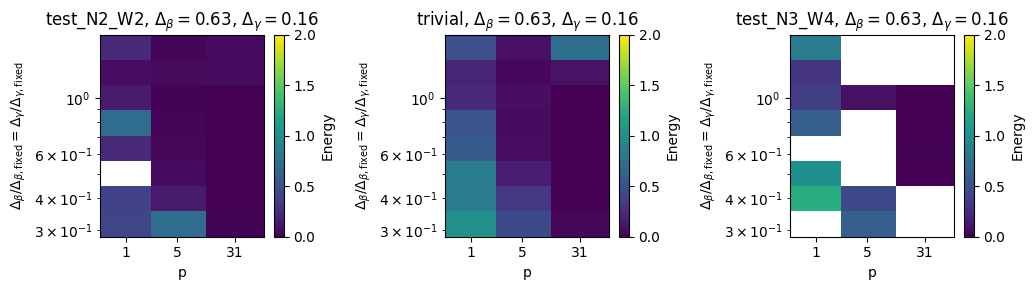

In [3]:
fig, axs = plt.subplots(1, 3)

delta_b_fixed = 0.63
delta_g_fixed = 0.16
plot(axs[0], 'test_N2_W2', delta_b_fixed, delta_g_fixed, '4000')
plot(axs[1], 'trivial', delta_b_fixed, delta_g_fixed, '4000')
plot(axs[2], 'test_N3_W4', delta_b_fixed, delta_g_fixed, '4000')


fig.set_figheight(3 * 1)
fig.set_figwidth(3.5 * len(axs))
plt.tight_layout()

In [4]:
def plot_dist(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    p, db, dg,
    max_beta_T=None, iters=None,
    normalise=True
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits
    if max_beta_T is None:
        with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.pkl', 'rb') as f:
            res = pickle.load(f)
    else:
        with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.betaT{max_beta_T}.pkl', 'rb') as f:
            res = pickle.load(f) 
        
    
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    
    keys = samples_dict.keys()
    true_key = None
    for key in keys:
        if key[0] == p and np.abs(key[1] * db - delta_b_fixed)**2 < 0.0005 and np.abs(key[1] * dg - delta_g_fixed)**2 < 0.0005:
            true_key = key
            break
    if true_key is None:
        raise Exception('Could not find key')
    print(filename, true_key)

    cutoff=25
    ax = axs[0]
    random_samples = np.random.choice(('0', '1'), (shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True)
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = -1', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        if len(samples_dict[true_key]) == 10:
            counter = Counter(samples_dict[true_key][iters[i-1]])
        else:
            counter = Counter(samples_dict[true_key][i-1])
        evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
        # all_energies = [count * [evals[idx]] for idx, count in enumerate(counter.values())]
        # all_sample_vals = np.array([x for xs in all_energies for x in xs])
        
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])
        # print([count for idx, count in enumerate(counter.values()) if evals[idx] < 1e-5])
        # print(np.mean(all_sample_vals))

        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]}', ha='right', va='top', transform=ax.transAxes)

    return axs

In [5]:
# fig, axs = plt.subplots(4, 4, sharey='row', sharex='col')
# p = 5
# delta_b_fixed = 0.63
# delta_g_fixed = 0.16
# rescale = 10**(0.0)
# axs0 = axs[0, :]
# axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# # axs4 = axs[4, :]
# # axs5 = axs[5, :]


# axs0 = plot_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)
# axs1 = plot_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)

# axs2 = plot_dist(axs2, 'test_N7_W2', (2*7)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)
# axs3 = plot_dist(axs3, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)

# for ax in axs[:, 0]:
#     ax.set_ylabel(r'Sample density')
    
# qubits = [8, 12,28, 40]
# for idx, ax in enumerate(axs[:, -1]):
#     twin = ax.twinx()
#     twin.set_yticks([])
#     twin.set_ylabel(f'{qubits[idx]} qubits')
    
# for ax in axs[-1, :]:  
#     ax.set_xlabel(r'Energy')  
    
# fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 4000$', fontsize=16)
# fig.set_figheight(3 * len(axs[:, 0]))
# fig.set_figwidth(3.5 * len(axs[0, :]))
# plt.tight_layout()


test_N7_W2 (5, np.int64(1))
test_N4_W5 (5, np.int64(1))


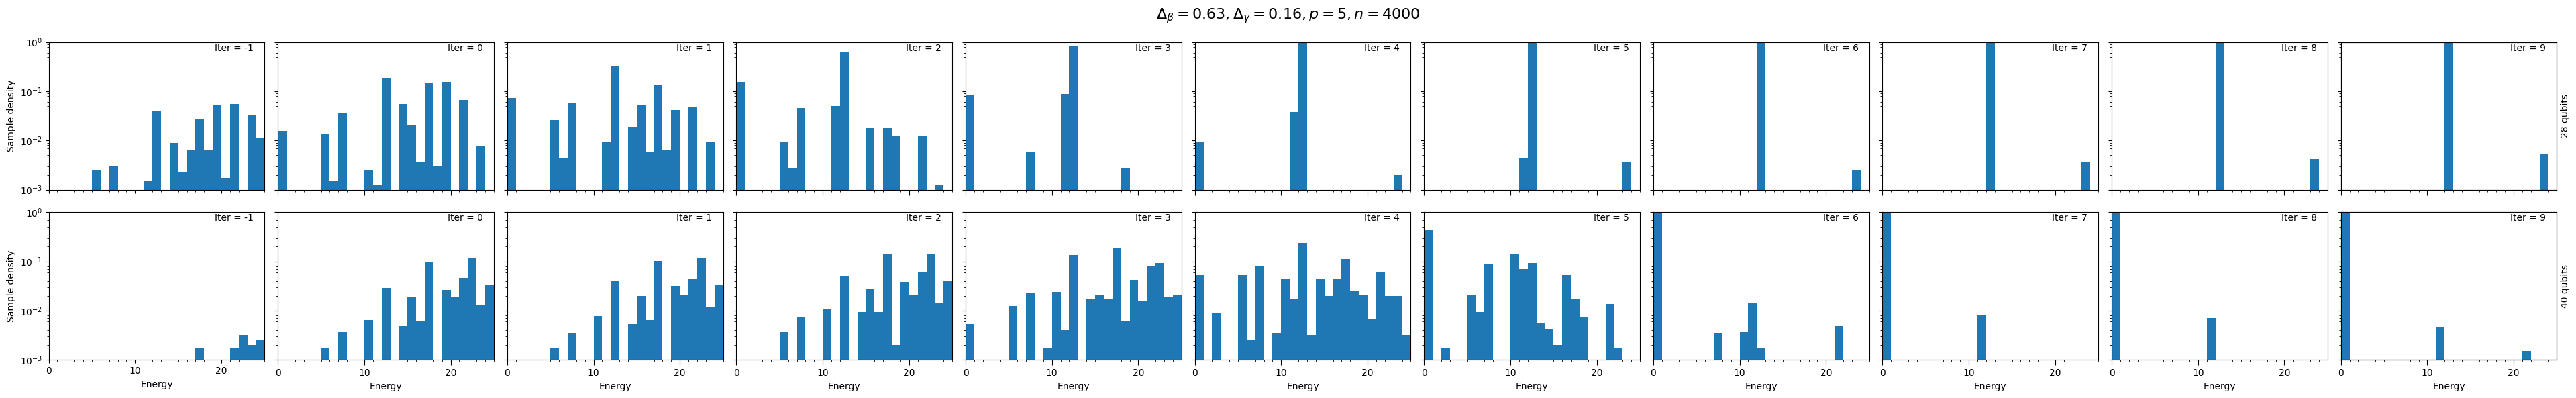

In [ ]:
fig, axs = plt.subplots(2, 11, sharey='row', sharex='col')
p = 5
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]
# axs5 = axs[5, :]


# axs0 = plot_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)
# axs1 = plot_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)

plot_dist(axs1, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False, max_beta_T=0.4, iters=range(10))

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


test_N7_W2 (1, np.int64(1))
test_N4_W5 (1, np.int64(1))


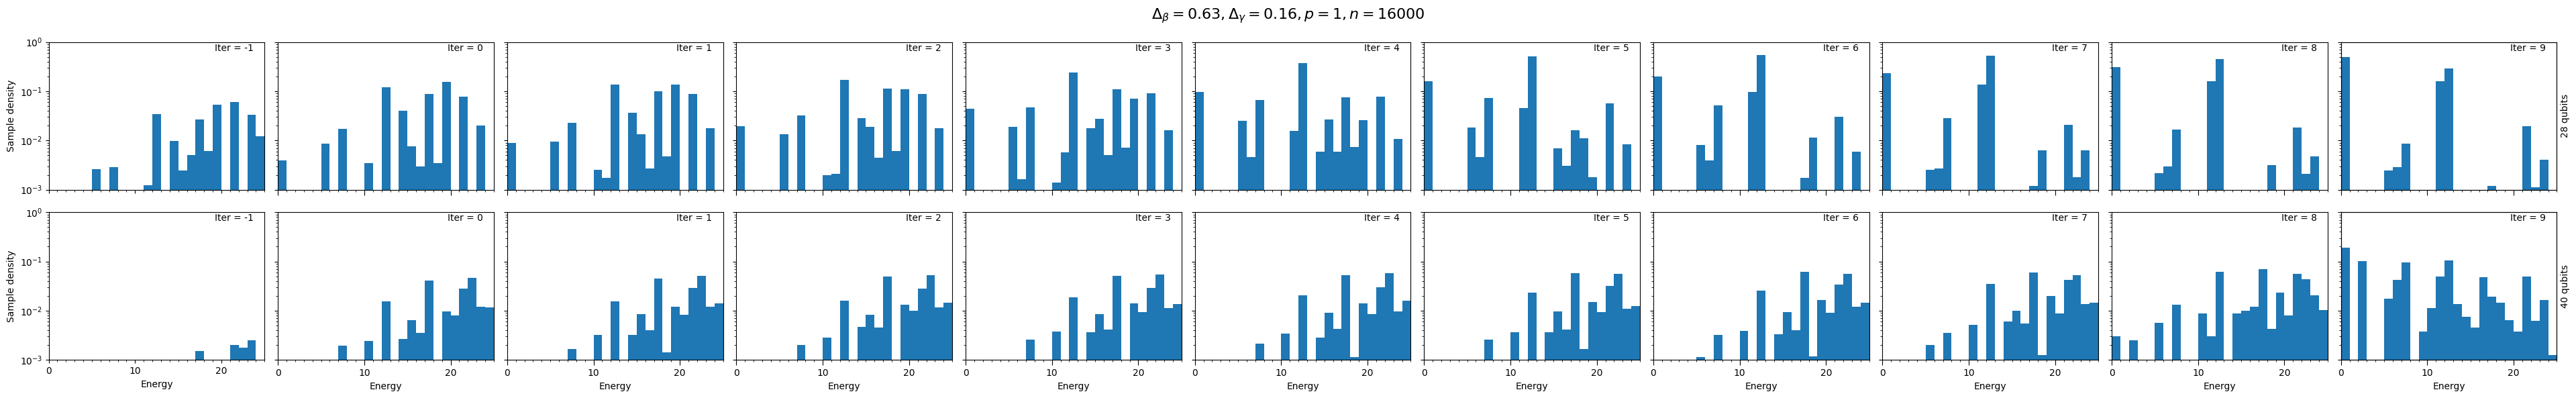

In [ ]:
fig, axs = plt.subplots(2, 11, sharey='row', sharex='col')
p = 1
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]
# axs5 = axs[5, :]


# axs0 = plot_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)
# axs1 = plot_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)

plot_dist(axs1, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 16000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False, max_beta_T=0.4, iters=range(10))

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 16000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


test_N4_W5 (5, np.int64(1))


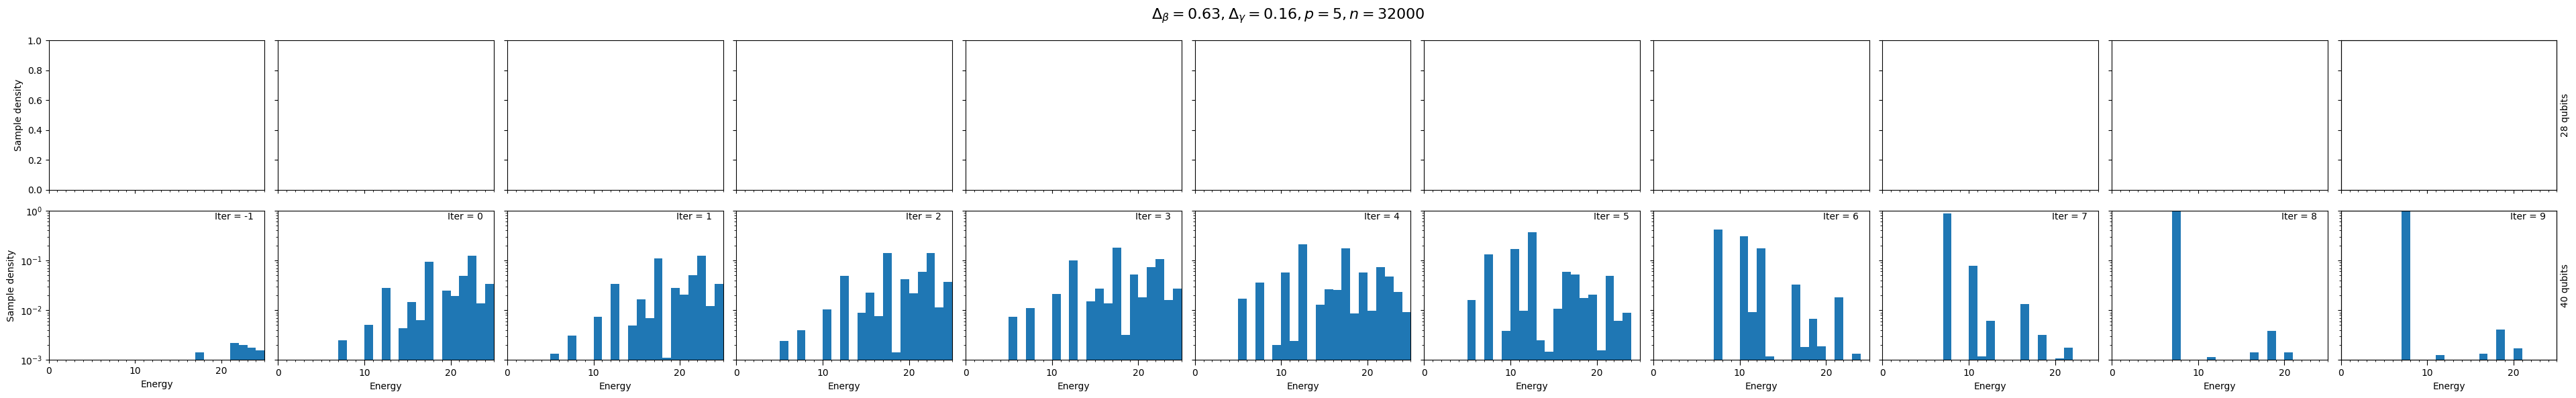

In [8]:
fig, axs = plt.subplots(2, 11, sharey='row', sharex='col')
p = 5
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]
# axs5 = axs[5, :]


# axs0 = plot_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)
# axs1 = plot_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 4000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False)

plot_dist(axs1, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 32000, p=p, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False, max_beta_T=0.4, iters=range(10))

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 32000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


test_N4_W5 (1, np.int64(1))
test_N4_W5 (5, np.int64(1))


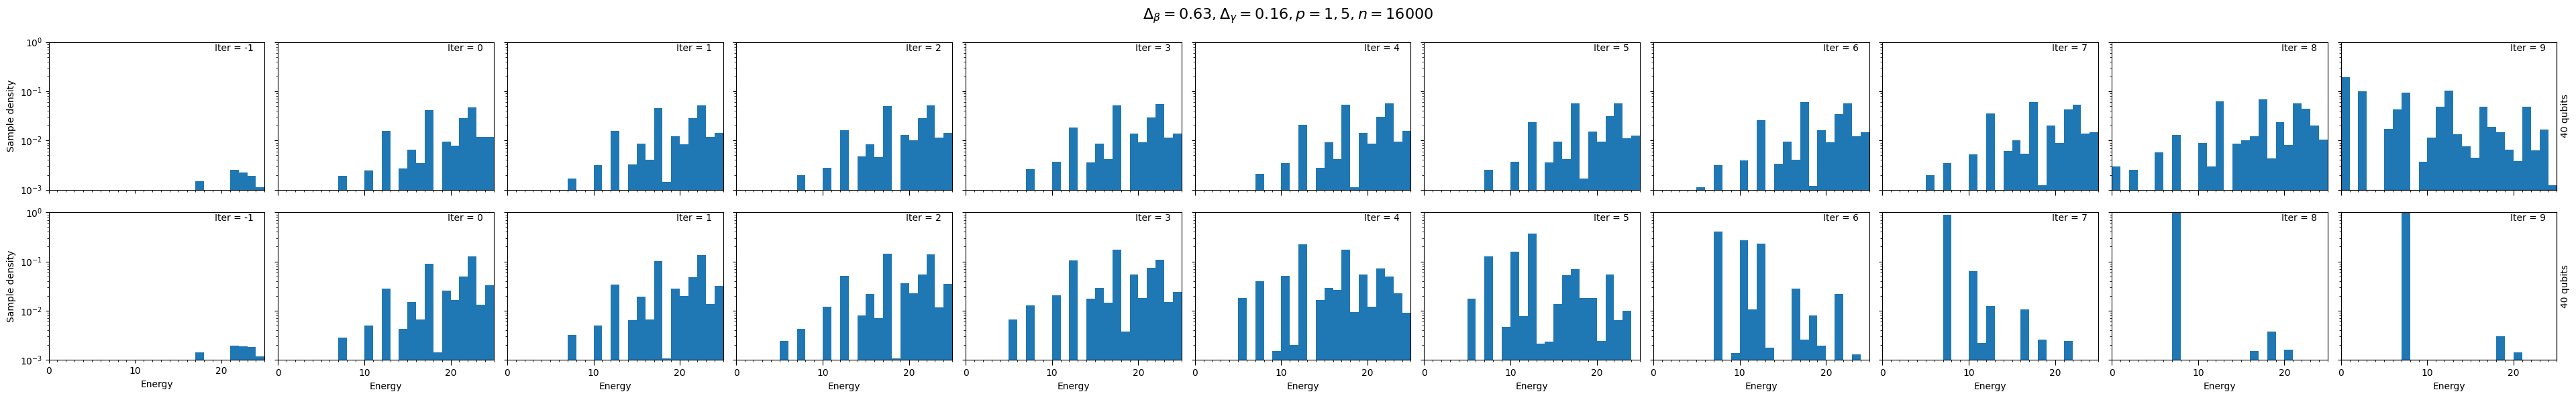

In [9]:
fig, axs = plt.subplots(2, 11, sharey='row', sharex='col')
# p = 5
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]
# axs5 = axs[5, :]

plot_dist(axs0, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 16000, p=1, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False, max_beta_T=0.4, iters=range(10))
plot_dist(axs1, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, 16000, p=5, db=delta_b_fixed*rescale, dg=delta_g_fixed*rescale, normalise=False, max_beta_T=0.4, iters=range(10))

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [40, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,5, n = 16000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


In [10]:
def plot_several_p_dist(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    ps, rescale,
    max_beta_T=None, eps=None, iters=None,
    normalise=False
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits
    if max_beta_T is None:
        with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.pkl', 'rb') as f:
            res = pickle.load(f)
    else:
        if eps is None:
            with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.betaT{max_beta_T}.pkl', 'rb') as f:
                res = pickle.load(f) 
        else:
            with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.betaT{max_beta_T}.eps{eps}.pkl', 'rb') as f:
                res = pickle.load(f) 
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    cutoff=25
    ax = axs[0]
    rand_shots = shots*10
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True)
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = -1', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for p in ps:
            rescale_value = None
            for key in keys:
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            if len(samples_dict[(p, rescale_value)]) > 3:
                counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
            else:
                counter = Counter(samples_dict[(p, rescale_value)][i-1])
            if i == len(axs) - 1:
                print(p, counter.most_common(2))
            evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
            
            energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
            sample_vals = np.array([x for xs in energies for x in xs])
            sample_sequence.append(sample_vals)

        ax.hist(sample_sequence, bins=range(cutoff+1), weights=[[1/shots]*len(sample_vals) for sample_vals in sample_sequence], rwidth=1, log=True, label=ps)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]}', ha='right', va='top', transform=ax.transAxes)
          
    ax.legend(loc='best', bbox_to_anchor=(0.8, 0.6, 0.2, 0.4))
    return axs

1 [('01000001', 2299), ('01001000', 371)]
3 [('01000001', 3999), ('01000101', 1)]
5 [('01000001', 3822), ('00100001', 58)]
1 [('010000000100000001', 3926), ('010000100100000001', 8)]
3 [('010000000100000001', 3988), ('010000000100000000', 2)]
5 [('000010001000100000', 3985), ('000010001010100000', 3)]
1 [('010000000010001000010000', 3005), ('010000000010001000000010', 194)]
3 [('000001000001100000000100', 1364), ('000100000001100000000100', 923)]
5 [('000001100000000100000001', 3975), ('000001100000000100000011', 3)]
1 [('0100000000000001001000000000010000000001', 3093), ('0100010000000001001000000000010000000001', 375)]
3 [('0100000000000001001000000000010000000001', 751), ('0100000000000001001000000010000000000100', 638)]
5 [('0000001000001000000000100000100000010000', 3810), ('0000001010001000000000100000100000010000', 67)]


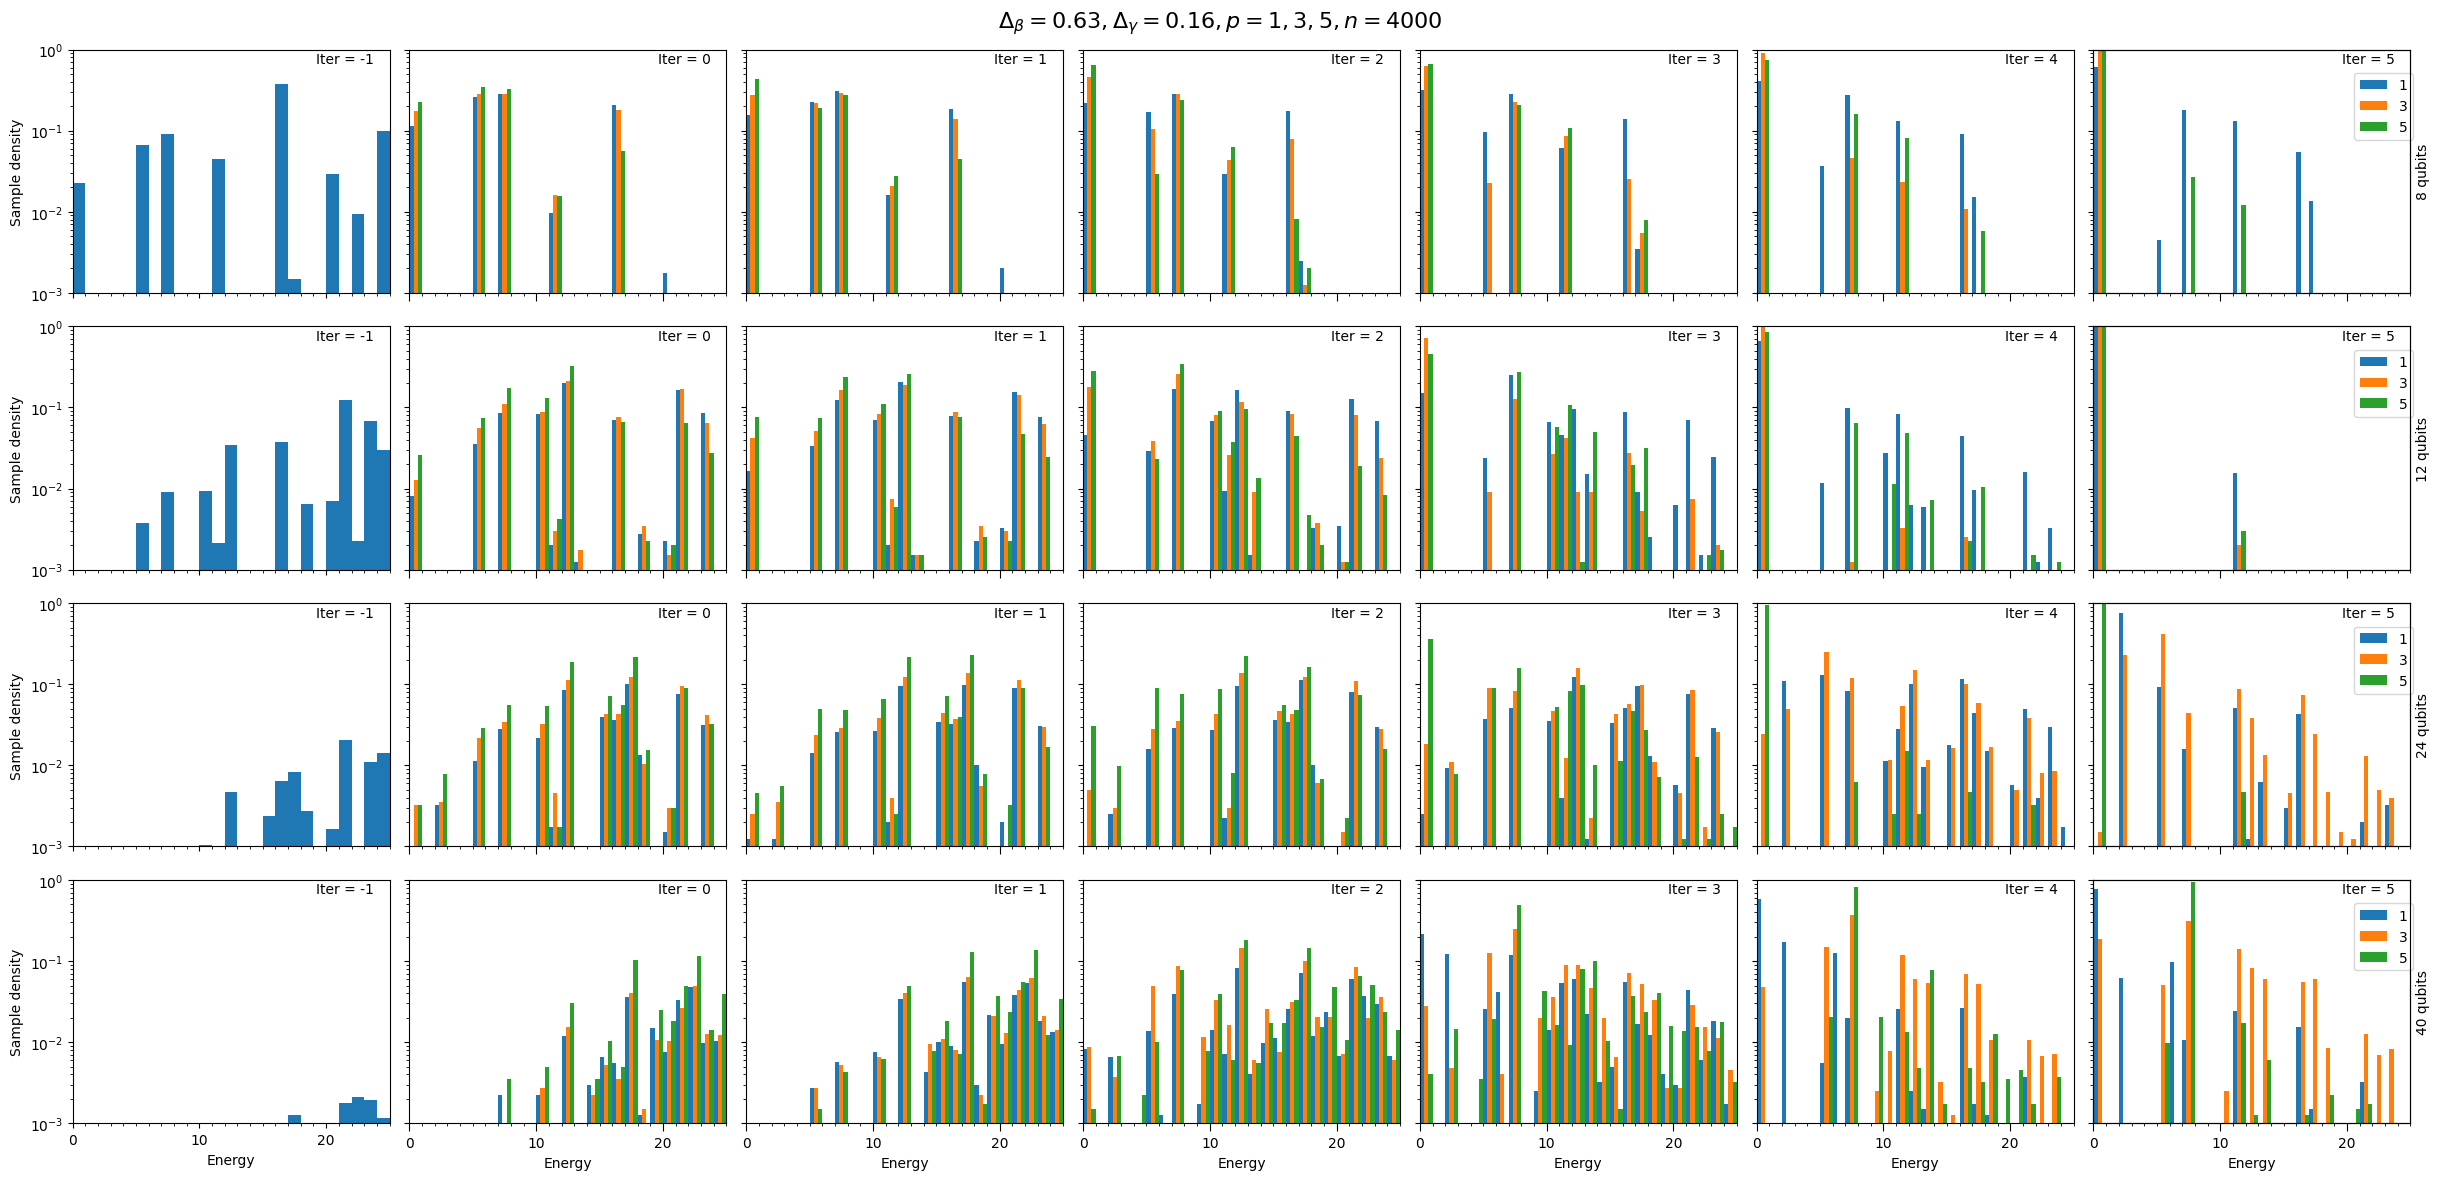

In [11]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 4000
ps = [1,3,5]
iters=range(6)
max_beta_T = 0.2
# ENERGIES ** 2, warm start

fig, axs = plt.subplots(4, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
# axs5 = axs[5, :]
plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters)
plot_several_p_dist(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters)
plot_several_p_dist(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters)
plot_several_p_dist(axs3, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8, 12, 24, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


1 [('01000001', 3016), ('00100001', 67)]
3 [('01000001', 3736), ('10000001', 41)]
5 [('01000001', 3659), ('01001000', 80)]
1 [('000010001000100000', 2100), ('000010001000010000', 41)]
3 [('000010001000100000', 3453), ('000010001000000000', 36)]
5 [('000010001000100000', 3605), ('000010001000000000', 20)]
1 [('000001100000000100000001', 1720), ('000001100000000100100000', 34)]
3 [('000100000001100000000100', 3218), ('000100000001100000000001', 38)]
5 [('000001100000000100000001', 3420), ('000001100000000100000000', 23)]
1 [('0000001000001000000100000000001010000000', 924), ('0000001000001000000100000000001000000001', 20)]
3 [('0000001000001000000100000000001010000000', 2782), ('0000001000001000000100000000000010000000', 45)]
5 [('0100000000000001000001000000000100100000', 2069), ('0100000000000001001000000000000100100000', 547)]


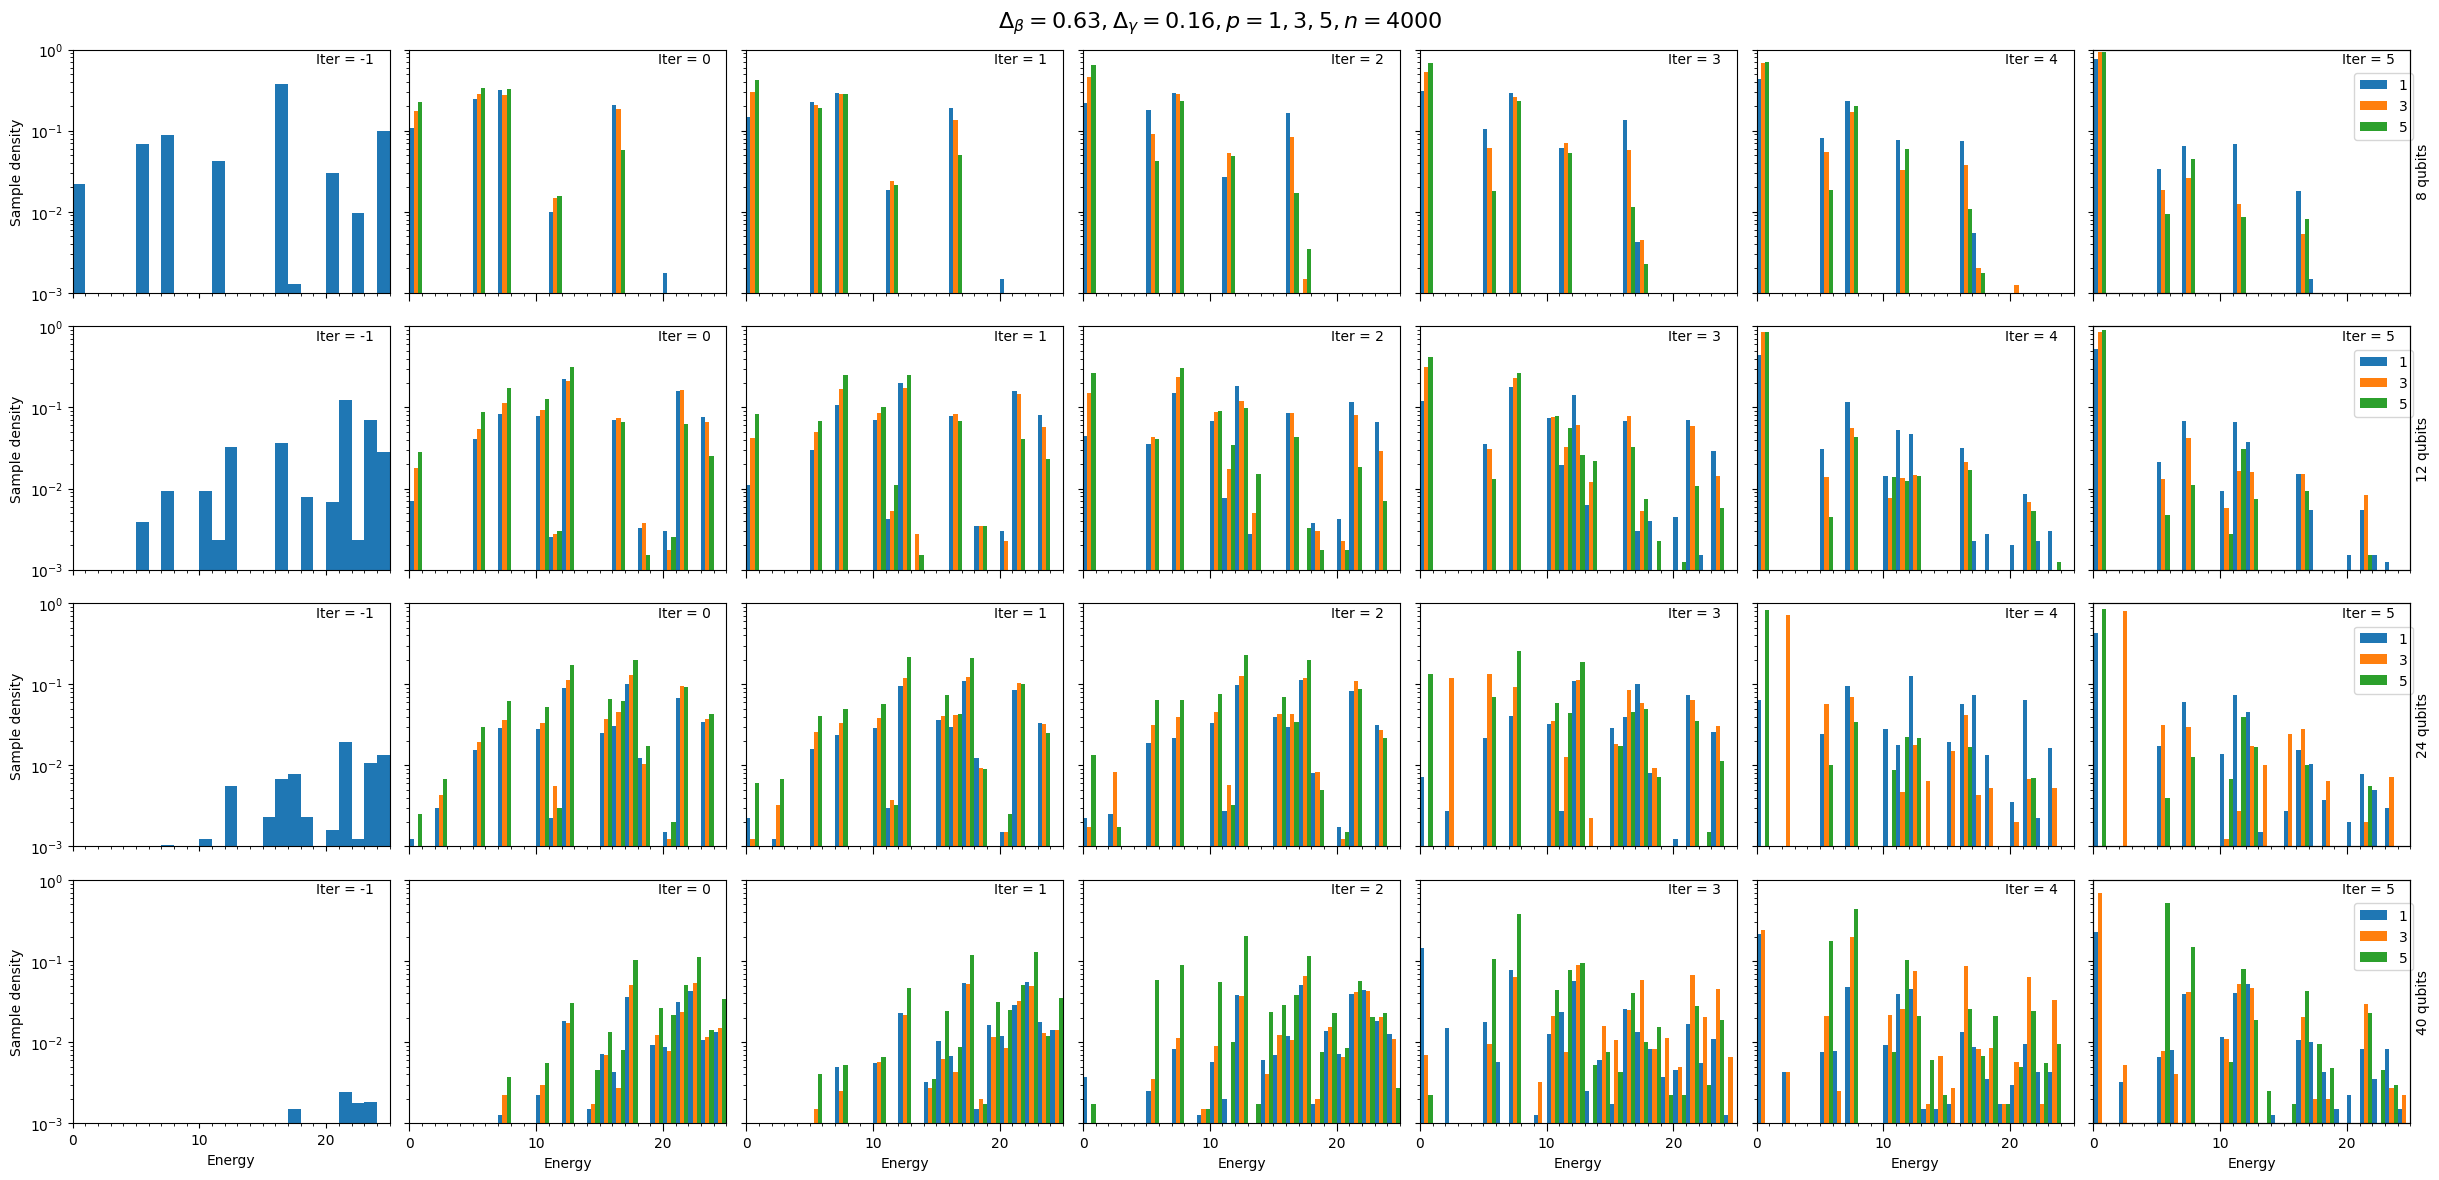

In [13]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)
eps = 0.1

n = 4000
ps = [1,3,5]
iters=range(6)
max_beta_T = 0.2
# ENERGIES ** 2, warm start, eps=0.1

fig, axs = plt.subplots(4, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
# axs5 = axs[5, :]
plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs3, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8, 12, 24, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


1 [('000000100000100000010000000000100000100010000000', 124), ('100000000000100000010000000000100000100010000000', 21)]
3 [('000000100000100000010000000000100000100010000000', 1517), ('000000100000100000010000000000100000100000000000', 96)]
5 [('000100000000001000001000000100000000001000001000', 1858), ('000100000000001000001000100100000000001000001000', 75)]
1 [('010000000000000001000000000001001000000000000010001000000000', 69), ('010000000000000001000000000001000000000000000010001000000000', 6)]
3 [('001000000000000010000000010000000010000000000001000000000001', 431), ('001000000000000010000000010000010000000000000001000000000001', 166)]
5 [('010000000000000001000001000000000010000000000001000000000001', 1538), ('010000000000000001000001000000000010000000000001000001000001', 34)]
1 [('0100000000000000000001000000000000000000000100000000000000000001', 9), ('0100000000000000000000000000000000000000000100000000000000000001', 6)]
3 [('0100000000000000000000000001000000000000000001000000

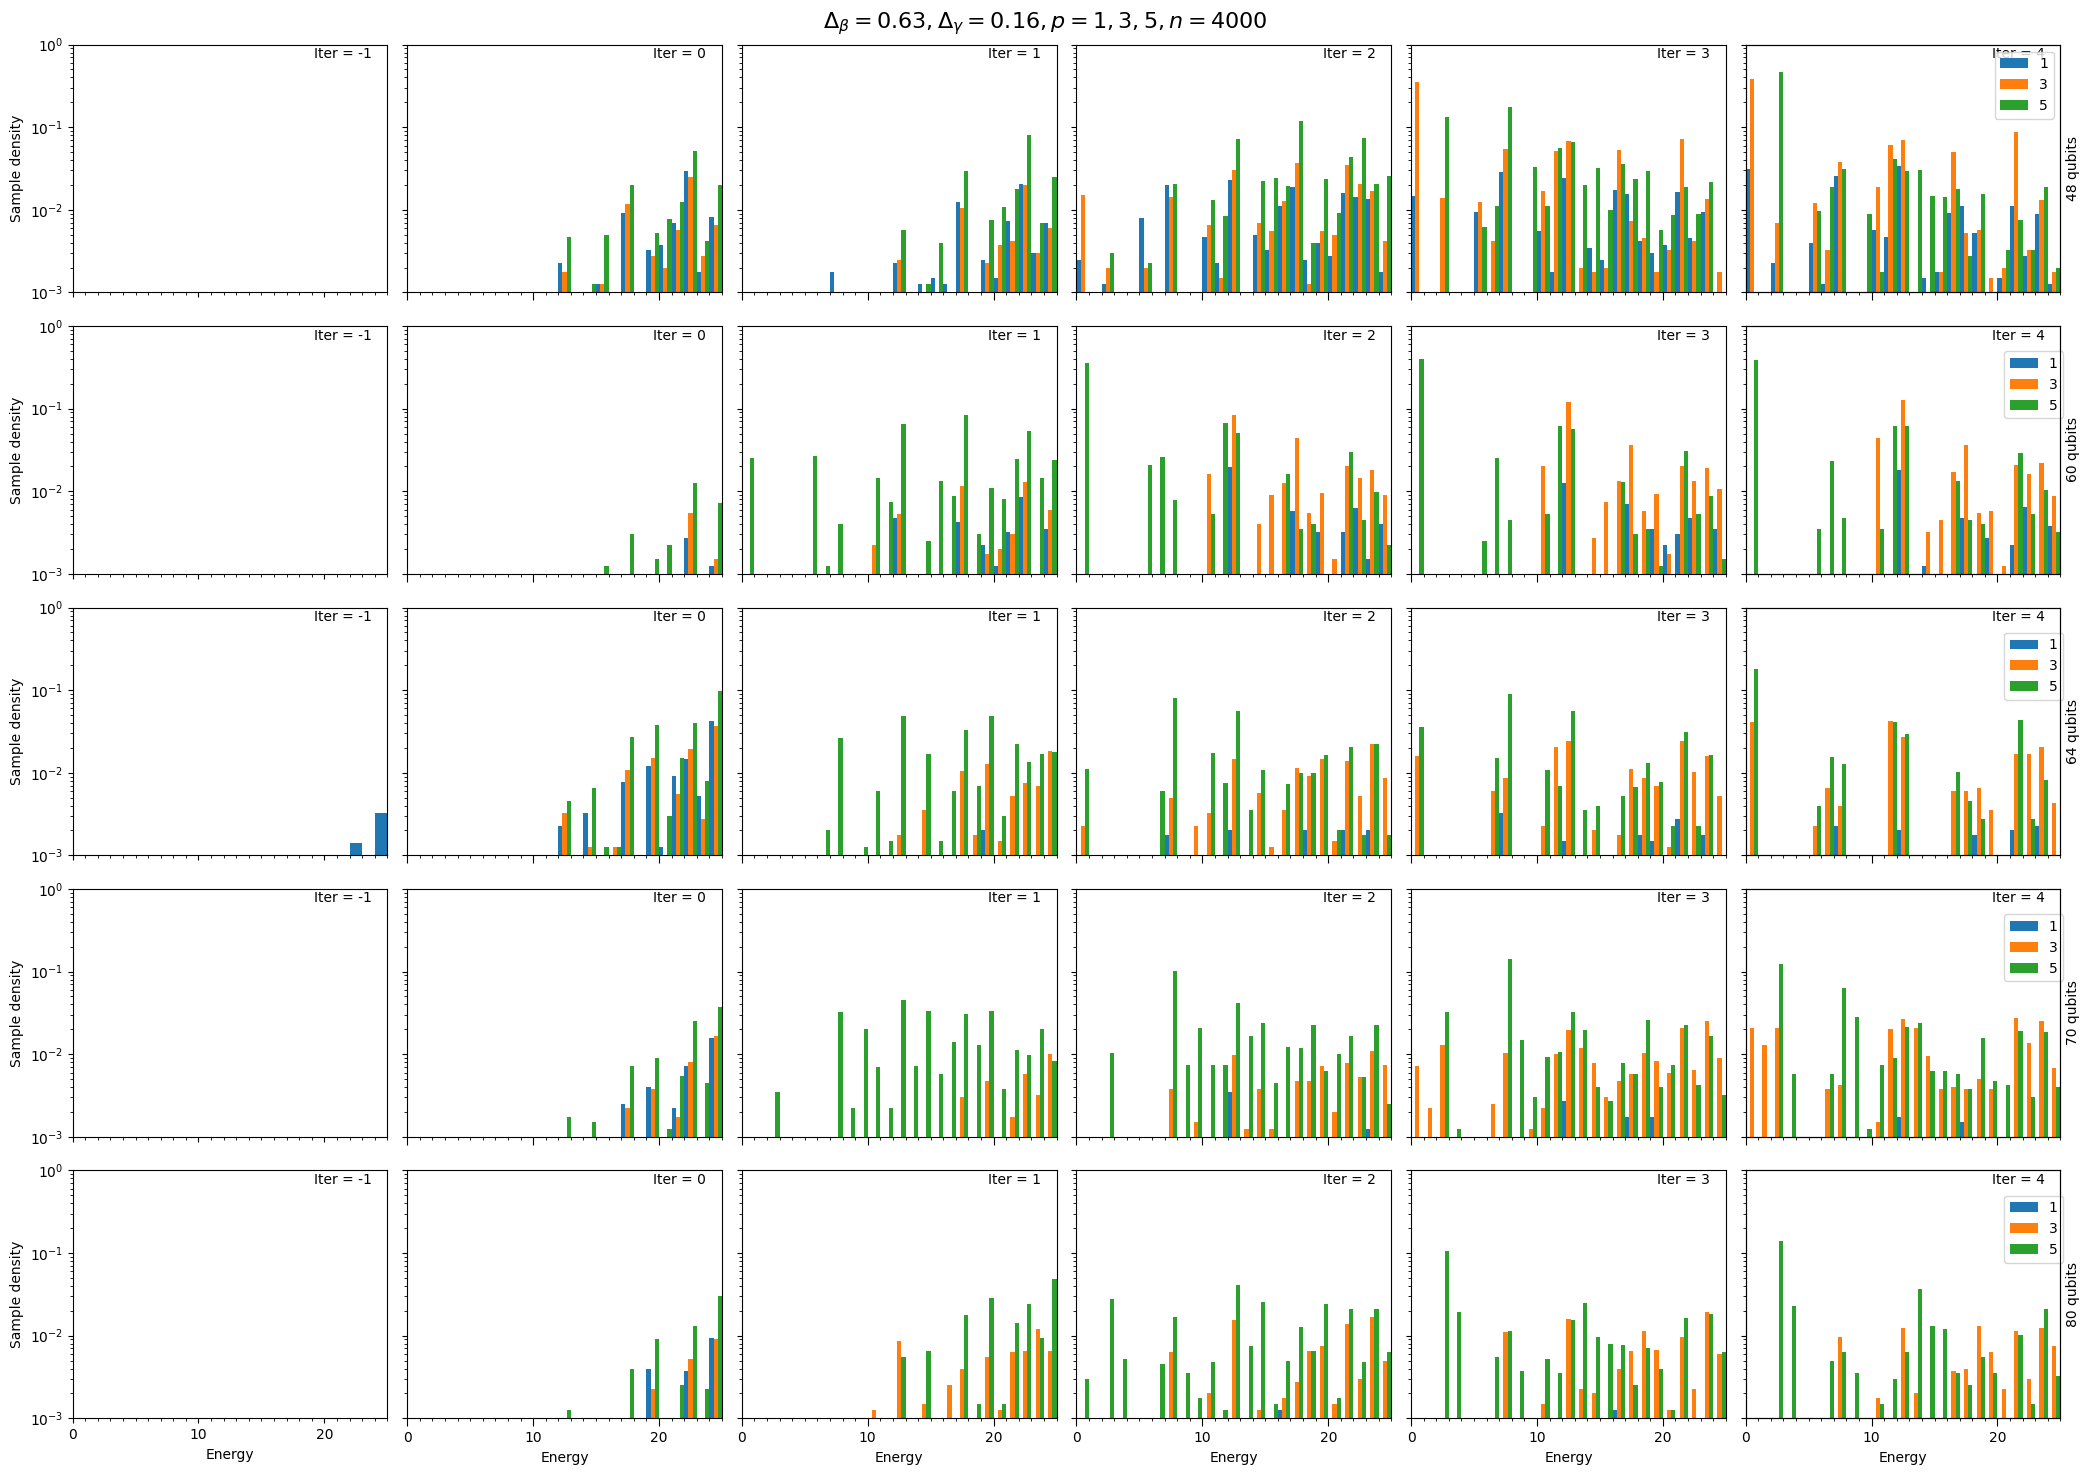

In [14]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)


n = 4000
ps = [1,3,5]
iters=range(5)
max_beta_T = 0.15
eps = 0.15
# ENERGIES ** 2, warm start, eps=0.1

fig, axs = plt.subplots(5, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
# axs5 = axs[5, :]
plot_several_p_dist(axs0, 'test_N4_W6', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs1, 'test_N5_W6', (2*5)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs2, 'test_N8_W4', (2*8)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs3, 'test_N7_W5', (2*7)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)
plot_several_p_dist(axs4, 'test_N8_W5', (2*8)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [48, 60, 64, 70, 80]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


In [15]:
s = '01000000000000000000010000000000000000000100000000000000000001000000000000000001'[::-1]
NN = 16
W = 5
[f'u{s[i*NN:(i+1)*NN].index("1") // 2}_{"+" if s[i*NN:(i+1)*NN].index("1") % 2 == 0 else "-"}' for i in range(W)]

['u0_+', 'u1_+', 'u3_+', 'u5_+', 'u7_+']

In [16]:
filename = 'test_N8_W5'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

Q, hamiltonian, offset, ising_offset = get_Q_and_hamiltonian(data_file)

In [17]:
evaluate_sparse_pauli_samples([s[::-1],], hamiltonian) + ising_offset

array([2.])

In [18]:
[int(x) for x in s] @ Q @ [int(x) for x in s] + offset

np.float64(2.0)